# Setup

In [2]:
# Import core and specialist libraries
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tqdm as notebook_tqdm

# Preprocessing, metrics, clustering, PCA, t-SNE, and UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import hdbscan, umap

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import statsmodels.api as sm
import statsmodels.formula.api as smf

import scipy.stats as stats


# Configure plotting styles and disable warnings
# import warnings
# warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


# EDA - Data Analysis

### Column Description

**FID:** FireID

**SRC_AGENCY:** Agency (province, territory, parks) from which the fire data has been obtained.

**FIRENAME:** Agency firename

**LATITUDE:** Latitude

**LONGITUDE:** Longitude

**REP_DATE:** Date of fire reported by individual agencies

**SIZE_HA:** Fire size in hectares

**CAUSE:** Cause of fire  
- U: Unknown cause
- L: Lightning caused fire
- H: Human caused fire
- H-PB: Prescribed burn (human caused)
- Re: Reburn

**PROTZONE:** Protection Zone as indicated by source agency. There is currently no official national standard that has been applied to this attribute.

**ECOZONE:** Ecodistrict associated with fire point location.

#### Load CSV

In [3]:
df = pd.read_csv('CANADA_WILDFIRES.csv')

df.head(10)

,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME
0,0,BC,59.963,-128.172,1953-05-26,8.0,H,,Boreal Cordillera
1,1,BC,59.318,-132.172,1950-06-22,8.0,L,,Boreal Cordillera
2,2,BC,59.876,-131.922,1950-06-04,12949.9,H,,Boreal Cordillera
3,3,BC,59.760,-132.808,1951-07-15,241.1,H,,Boreal Cordillera
4,4,BC,59.434,-126.172,1952-06-12,1.2,H,,Boreal Cordillera
5,5,BC,59.963,-136.502,1951-08-01,194.2,H,,Boreal Cordillera
6,6,BC,59.597,-126.728,1952-08-11,0.6,H,,Boreal Cordillera
7,7,BC,57.463,-122.816,1950-06-14,2071.9,L,,Taiga Plain
8,8,BC,57.126,-122.762,1950-06-13,0.1,H,,Taiga Plain
9,9,BC,57.684,-121.925,1953-05-01,7834.7,H,,Taiga Plain


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 423831 entries, 0 to 423830
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   FID         423831 non-null  int64  
 1   SRC_AGENCY  423831 non-null  str    
 2   LATITUDE    423831 non-null  float64
 3   LONGITUDE   423831 non-null  float64
 4   REP_DATE    420118 non-null  str    
 5   SIZE_HA     423831 non-null  float64
 6   CAUSE       423590 non-null  str    
 7   PROTZONE    422821 non-null  str    
 8   ECOZ_NAME   423831 non-null  str    
dtypes: float64(3), int64(1), str(5)
memory usage: 42.2 MB


In [5]:
df.describe()

,FID,LATITUDE,LONGITUDE,SIZE_HA
count,423831.000000,423831.000000,423831.000000,4.238310e+05
mean,211915.000000,51.895936,-104.253547,3.162710e+02
std,122349.615308,4.467770,20.412661,5.617050e+03
min,0.000000,0.000000,-166.044000,0.000000e+00
25%,105957.500000,49.133700,-120.112350,1.000000e-01
50%,211915.000000,51.023000,-114.503000,1.000000e-01
75%,317872.500000,54.630289,-88.303603,1.000000e+00
max,423830.000000,70.000000,116.188000,1.050000e+06


### Unique entries for PROTZONE
As stated: "There is currently no official national standard that has been applied to this attribute."

Which means every agency does it differently and therefore this column will have many unique values with no convention.

In [6]:
unique_PROTZONE = df['PROTZONE'].unique()
print(unique_PROTZONE)
print()
print(df['PROTZONE'].value_counts(dropna=False))

<ArrowStringArray>
[                    ' ',                   'EXT',             'Intensive',
  'W (Observation Zone)',      'G (Low Priority)',     'R (High Priority)',
 'Y (Moderate Priority)',                     nan,                   'MOD',
                   'MON',                   'FUL',                   'MDP',
                   'SUP',                   'MNP',              'nordique',
              'Nordique',             'intensive',         'ActionCode: 1',
         'ActionCode: 2',          'FullResponse', 'Wilderness (forested)',
                  'Full',              'Critical',             'Strategic',
        'Wilderness FMZ',         'Stratigic FMZ',          'Critical FMZ',
        'Transition FMZ',              'Full FMZ',          'Transitional',
        'Initial Attack',       'Being Monitored',      'Sustained Action',
        'Limited Action',        'Delayed Action',             'Monitored',
             'Abandoned',     'Modified Response',         'Full Resp

In [7]:
print(unique_PROTZONE.tolist())

[' ', 'EXT', 'Intensive', 'W (Observation Zone)', 'G (Low Priority)', 'R (High Priority)', 'Y (Moderate Priority)', nan, 'MOD', 'MON', 'FUL', 'MDP', 'SUP', 'MNP', 'nordique', 'Nordique', 'intensive', 'ActionCode: 1', 'ActionCode: 2', 'FullResponse', 'Wilderness (forested)', 'Full', 'Critical', 'Strategic', 'Wilderness FMZ', 'Stratigic FMZ', 'Critical FMZ', 'Transition FMZ', 'Full FMZ', 'Transitional', 'Initial Attack', 'Being Monitored', 'Sustained Action', 'Limited Action', 'Delayed Action', 'Monitored', 'Abandoned', 'Modified Response', 'Full Response', 'Prescribed Fire', 'Monitored Response']


### Unique Entries for SRC_AGENCY

In [8]:
unique_AGENCY = df['SRC_AGENCY'].unique()
print(unique_AGENCY)
print()
print(df['SRC_AGENCY'].value_counts(dropna=False))

<ArrowStringArray>
[      'BC',       'AB',       'SK',       'MB',       'ON',       'QC',
       'NL',       'NB',       'NS',       'YT',       'NT',    'PC-NA',
    'PC-WB',    'PC-VU',    'PC-BA',    'PC-EI',    'PC-WP',    'PC-JA',
    'PC-PA',    'PC-GL',    'PC-KO',    'PC-RE',    'PC-BT',    'PC-YO',
    'PC-RM',    'PC-GF',    'PC-GR',    'PC-WL',    'PC-FR',    'PC-PU',
    'PC-KG',    'PC-LM',    'PC-CB',    'PC-PE',    'PC-BP',    'PC-TI',
    'PC-SL',    'PC-KE',    'PC-PP',    'PC-SY',    'PC-SE',    'PC-NC',
    'PC-KL', 'PC-RE-GL',    'PC-GM',    'PC-PR',    'PC-TN',    'PC-GI',
    'PC-FW',    'PC-FO',    'PC-GB',    'PC-LO',    'PC-RO',    'PC-FU',
    'PC-MM',    'PC-TH']
Length: 56, dtype: str

SRC_AGENCY
BC          149410
ON           63508
AB           62707
QC           43124
MB           27508
SK           25287
NT           14365
NB           11041
NS           10451
YT            8061
NL            4372
PC-WB         1961
PC-BA          353
PC-JA          25

### Graph Exploration

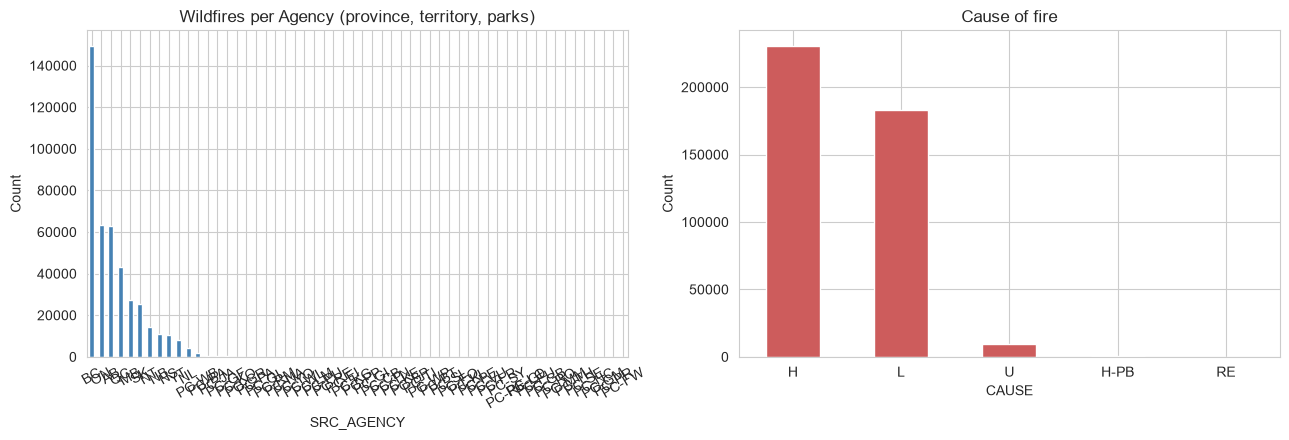

In [9]:
# create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1,2, figsize=(13,4.5))

df["SRC_AGENCY"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Wildfires per Agency (province, territory, parks)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

df["CAUSE"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Cause of fire")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# render plots
plt.tight_layout()
plt.show()

## Data-Cleaning

### 1. Covert dates to pandas datetime object

We can then use this datetime object to extract the month and then group them into seasons to determine when wildfires are most frequent.

In [10]:
df["REP_DATE"].head()

0    1953-05-26
1    1950-06-22
2    1950-06-04
3    1951-07-15
4    1952-06-12
Name: REP_DATE, dtype: str

In [11]:
df['DATE_OBJ'] = pd.to_datetime(df['REP_DATE'], format='%Y-%m-%d')
df["DATE_OBJ"].head()


0   1953-05-26
1   1950-06-22
2   1950-06-04
3   1951-07-15
4   1952-06-12
Name: DATE_OBJ, dtype: datetime64[us]

In [12]:
df['YEAR'] = df['DATE_OBJ'].dt.year
df['MONTH'] = df['DATE_OBJ'].dt.month
df['MONTH_NAME'] = pd.to_datetime(df['MONTH'], format='%m').dt.month_name().str[:3]
df.head(5)

,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME,DATE_OBJ,YEAR,MONTH,MONTH_NAME
0,0,BC,59.963,-128.172,1953-05-26,8.0,H,,Boreal Cordillera,1953-05-26,1953.0,5.0,May
1,1,BC,59.318,-132.172,1950-06-22,8.0,L,,Boreal Cordillera,1950-06-22,1950.0,6.0,Jun
2,2,BC,59.876,-131.922,1950-06-04,12949.9,H,,Boreal Cordillera,1950-06-04,1950.0,6.0,Jun
3,3,BC,59.760,-132.808,1951-07-15,241.1,H,,Boreal Cordillera,1951-07-15,1951.0,7.0,Jul
4,4,BC,59.434,-126.172,1952-06-12,1.2,H,,Boreal Cordillera,1952-06-12,1952.0,6.0,Jun


### 2. Create `SEASONS` Column

In [13]:
# cast to int
df['MONTH'] = df['MONTH'].astype("Int64")
df['YEAR'] = df['YEAR'].astype("Int64")

# dictionary
seasons_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}

# mapping
df['SEASON'] = df['MONTH'].map(seasons_map)

df.head(5)

,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME,DATE_OBJ,YEAR,MONTH,MONTH_NAME,SEASON
0,0,BC,59.963,-128.172,1953-05-26,8.0,H,,Boreal Cordillera,1953-05-26,1953,5,May,Spring
1,1,BC,59.318,-132.172,1950-06-22,8.0,L,,Boreal Cordillera,1950-06-22,1950,6,Jun,Summer
2,2,BC,59.876,-131.922,1950-06-04,12949.9,H,,Boreal Cordillera,1950-06-04,1950,6,Jun,Summer
3,3,BC,59.760,-132.808,1951-07-15,241.1,H,,Boreal Cordillera,1951-07-15,1951,7,Jul,Summer
4,4,BC,59.434,-126.172,1952-06-12,1.2,H,,Boreal Cordillera,1952-06-12,1952,6,Jun,Summer


### 3. Remove rows outside of BC

Since the client is the BC Wildfire Service (BCWS), fires outside of the province do not count towards the study. 

In [14]:
df = df[df['SRC_AGENCY'] == 'BC'].reset_index()
df['SRC_AGENCY'].nunique()

1

### 4. Remove NaN/Null/missing values

Columns affected: `REP_DATE`, `CAUSE`

We can't analyze entries without a proper date or an unknown cause since we can't predict them.

In [15]:
df.dropna(subset=['REP_DATE'], inplace=True)
df.dropna(subset=['CAUSE'], inplace=True)

causes_valid = ["H", "L"]
df = df[df["CAUSE"].isin(causes_valid)].reset_index()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149185 entries, 0 to 149184
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   level_0     149185 non-null  int64         
 1   index       149185 non-null  int64         
 2   FID         149185 non-null  int64         
 3   SRC_AGENCY  149185 non-null  str           
 4   LATITUDE    149185 non-null  float64       
 5   LONGITUDE   149185 non-null  float64       
 6   REP_DATE    149185 non-null  str           
 7   SIZE_HA     149185 non-null  float64       
 8   CAUSE       149185 non-null  str           
 9   PROTZONE    149185 non-null  str           
 10  ECOZ_NAME   149185 non-null  str           
 11  DATE_OBJ    149185 non-null  datetime64[us]
 12  YEAR        149185 non-null  Int64         
 13  MONTH       149185 non-null  Int64         
 14  MONTH_NAME  149185 non-null  str           
 15  SEASON      149185 non-null  str           
dtypes: Int64(2), 

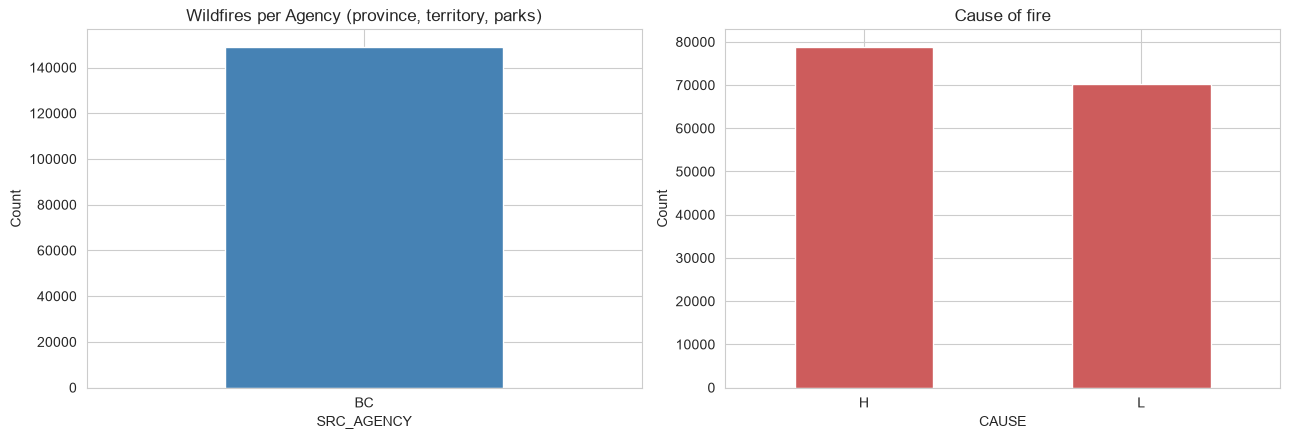

In [16]:
# create subplots with 1 row and 2 columns
fig, axes = plt.subplots(1,2, figsize=(13,4.5))

df["SRC_AGENCY"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Wildfires per Agency (province, territory, parks)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["CAUSE"].value_counts().plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_title("Cause of fire")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# render plots
plt.tight_layout()
plt.show()

### Checkpoint 1 — Client Check-in 

After finishing my initial EDA I decided to check with Manmeet for feedback. Here's what they had to say:

> "i think you still need to filter the data to 2002-2021 since thats the 20 year range we decided on in the proposal. right now it looks like its still including fires going back to the 1950s.

> for the clustering, i think it could definitely be useful for finding patterns between regions/seasons etc. but just keep in mind the main goal for option c is predicting whether a fire is human or lightning caused. 

> since we already have h/l as labels, i think a classification model would make more sense for that part, and clustering could be an extra analysis alongside it.

> and for size_ha, yeah i think logging it makes sense since the fire sizes vary a lot and the really huge fires could throw off the clustering."

I continued my EDA with these points in mind.

### 5. Filter data to 2002-2021 (20 year range)

In [17]:
filtered_df = df[df['DATE_OBJ'].between('2002-01-01', '2021-06-30')]
df = filtered_df
df.head()

,level_0,index,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME,DATE_OBJ,YEAR,MONTH,MONTH_NAME,SEASON
105308,105315,105315,105315,BC,55.8000,-124.8167,2005-06-20,0.010,L,,Montane Cordillera,2005-06-20,2005,6,Jun,Summer
109881,109899,109899,109899,BC,59.2448,-131.9168,2003-07-01,0.009,L,,Boreal Cordillera,2003-07-01,2003,7,Jul,Summer
109938,109956,109956,109956,BC,59.7096,-135.0619,2003-06-06,0.010,H,,Boreal Cordillera,2003-06-06,2003,6,Jun,Summer
109986,110004,110004,110004,BC,59.4583,-136.3750,2003-08-27,0.300,H,,Pacific Maritime,2003-08-27,2003,8,Aug,Summer
109999,110017,110017,110017,BC,59.1910,-129.2325,2003-05-05,0.100,H,,Boreal Cordillera,2003-05-05,2003,5,May,Spring


In [18]:
df.tail()

,level_0,index,FID,SRC_AGENCY,LATITUDE,LONGITUDE,REP_DATE,SIZE_HA,CAUSE,PROTZONE,ECOZ_NAME,DATE_OBJ,YEAR,MONTH,MONTH_NAME,SEASON
149180,149405,149405,149405,BC,49.2905,-116.6513,2021-03-28,7.600,H,,Montane Cordillera,2021-03-28,2021,3,Mar,Spring
149181,149406,149406,149406,BC,50.5044,-116.0926,2021-03-28,0.009,H,,Montane Cordillera,2021-03-28,2021,3,Mar,Spring
149182,149407,149407,149407,BC,49.1363,-119.4594,2021-03-28,2.000,H,,Montane Cordillera,2021-03-28,2021,3,Mar,Spring
149183,149408,149408,149408,BC,50.5535,-121.2930,2021-04-02,0.500,H,,Montane Cordillera,2021-04-02,2021,4,Apr,Spring
149184,149409,149409,149409,BC,50.0441,-120.8569,2021-04-04,50.000,H,,Montane Cordillera,2021-04-04,2021,4,Apr,Spring


### 6. Double checking unique values
Since we might be using this in our model later as additional context, I should double check for 0 values and clean up any columns with inefficent naming.

In [19]:
print("PROTZONE unique representations:")
print(repr(df['PROTZONE'].unique()[:10]))
print(df['PROTZONE'].value_counts(dropna=False))

print("\nCAUSE value counts:")
print(df['CAUSE'].value_counts(dropna=False))

print("\nECOZ_NAME value counts:")
print(df['ECOZ_NAME'].value_counts(dropna=False))

print("\nSRC_AGENCY value counts:")
print(df['SRC_AGENCY'].value_counts(dropna=False))

print("\nZero / Min values in SIZE_HA:")
print((df['SIZE_HA'] == 0).sum(), "zeros out of", len(df))
print((df['SIZE_HA'] < 0).sum(), "negative values")

PROTZONE unique representations:
<ArrowStringArray>
[' ']
Length: 1, dtype: str
PROTZONE
    32406
Name: count, dtype: int64

CAUSE value counts:
CAUSE
L    19390
H    13016
Name: count, dtype: int64

ECOZ_NAME value counts:
ECOZ_NAME
Montane Cordillera    24828
Pacific Maritime       4891
Boreal PLain           1247
Taiga Plain            1047
Boreal Cordillera       389
                          4
Name: count, dtype: int64

SRC_AGENCY value counts:
SRC_AGENCY
BC    32406
Name: count, dtype: int64

Zero / Min values in SIZE_HA:
139 zeros out of 32406
0 negative values


In [20]:
print("Unique values for each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unique values for each column:
level_0: 32406 unique values
index: 32406 unique values
FID: 32406 unique values
SRC_AGENCY: 1 unique values
LATITUDE: 24642 unique values
LONGITUDE: 27431 unique values
REP_DATE: 3964 unique values
SIZE_HA: 1674 unique values
CAUSE: 2 unique values
PROTZONE: 1 unique values
ECOZ_NAME: 6 unique values
DATE_OBJ: 3964 unique values
YEAR: 20 unique values
MONTH: 12 unique values
MONTH_NAME: 12 unique values
SEASON: 4 unique values


By checking these values, we know we can drop the `PROTZONE` column entirely and remove any zero value rows in `SIZE_HA`

In [21]:
df_new = df.drop(columns='PROTZONE') #empty column
df = df[df_new['SIZE_HA'] != 0] #remove zeros

print("Zero / Min values in SIZE_HA:")
print((df['SIZE_HA'] == 0).sum(), "zeros out of", len(df))

Zero / Min values in SIZE_HA:
0 zeros out of 32267


### 6. Logging `SIZE_HA` for Logistic Regression
`SIZE_HA` ranges from 0.0 hectares up to 521,012 hectares. This means both the median and mean will be heavily skewed and pull the model towards an extreme.


In [22]:
df['LOG_SIZE_HA'] = np.log1p(df['SIZE_HA'])

print(f"Raw distribution skewness: {df['SIZE_HA'].skew():.4f}")
print(f"Log-transformed distribution skewness: {df['LOG_SIZE_HA'].skew():.4f}")

Raw distribution skewness: 81.1276
Log-transformed distribution skewness: 3.4339


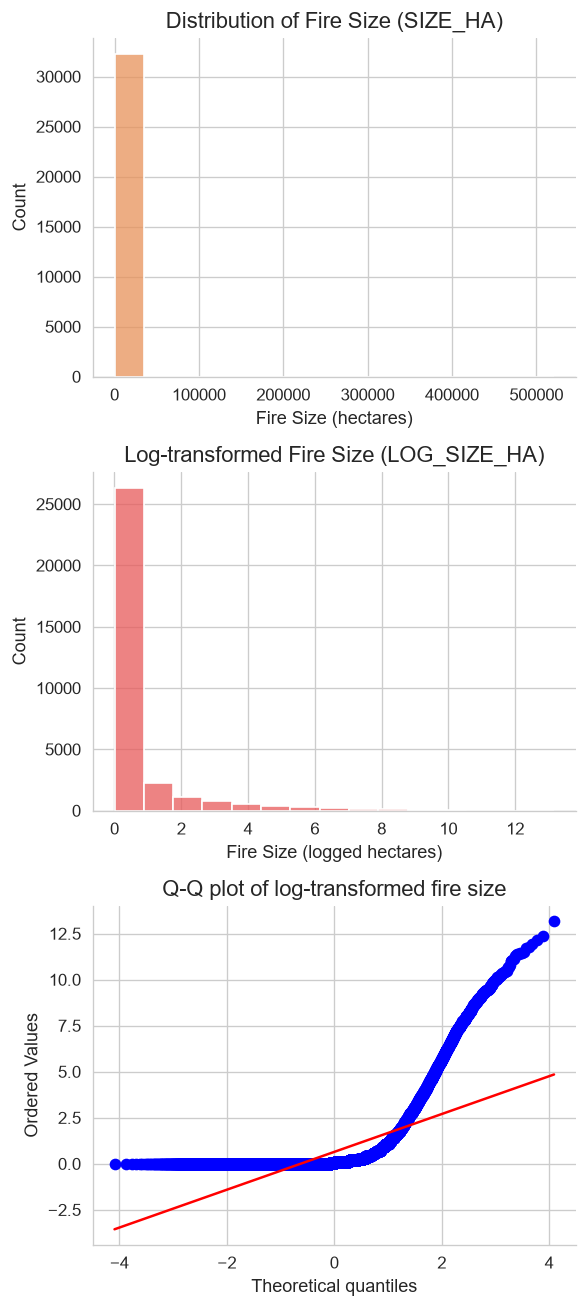

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

fig, axes = plt.subplots(3, 1, figsize=(5, 11))

outcome = df['SIZE_HA']
outcome_logged = df['LOG_SIZE_HA']

# Draw histogram of raw outcome distribution
sns.histplot(outcome,
             color="#e8925a",
             bins=15,
             ax=axes[0])
axes[0].set_title("Distribution of Fire Size (SIZE_HA)")
axes[0].set_xlabel("Fire Size (hectares)")

# Draw histogram of log-transformed outcome distribution
sns.histplot(outcome_logged,
             color="#e85a5a",
             bins=15,
             ax=axes[1])
axes[1].set_title("Log-transformed Fire Size (LOG_SIZE_HA)")
axes[1].set_xlabel("Fire Size (logged hectares)")

# Q-Q plot comparing log-transformed distribution to a normal distribution
stats.probplot(outcome_logged, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q plot of log-transformed fire size")

sns.despine()
plt.tight_layout()
plt.show()

### 7. Drop redundant columns
To avoid overfitting, we drop columns with redundant information (For example, `SRC_AGENCY` has only one value of BC due to filtering) or no values (`FID` is simply a label).

In [24]:
cols_to_drop = ['level_0', 'index', 'FID', 'SRC_AGENCY', 'PROTZONE', 'REP_DATE', 'DATE_OBJ', 'MONTH_NAME']
df_clean = df.drop(columns=cols_to_drop)

### 8. Save cleaned dataset

In [25]:
df_clean.to_csv("BC_WILDFIRES.csv", index=False)
print("Saved clean dataset")

Saved clean dataset


# Checkpoint 2 — Problems substantially modeled

In [3]:
df = pd.read_csv("BC_WILDFIRES.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32267 entries, 0 to 32266
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LATITUDE     32267 non-null  float64
 1   LONGITUDE    32267 non-null  float64
 2   SIZE_HA      32267 non-null  float64
 3   CAUSE        32267 non-null  str    
 4   ECOZ_NAME    32267 non-null  str    
 5   YEAR         32267 non-null  int64  
 6   MONTH        32267 non-null  int64  
 7   SEASON       32267 non-null  str    
 8   LOG_SIZE_HA  32267 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 3.0 MB


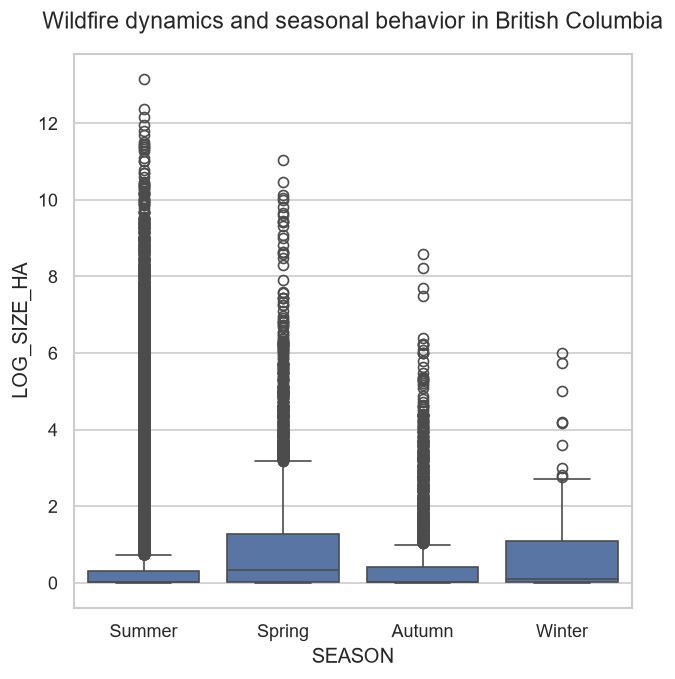

In [82]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, x='SEASON', y='LOG_SIZE_HA')
plt.title(
    "Wildfire dynamics and seasonal behavior in British Columbia", fontsize=14, pad=15
)
plt.show()

## 1. Disproving Option A

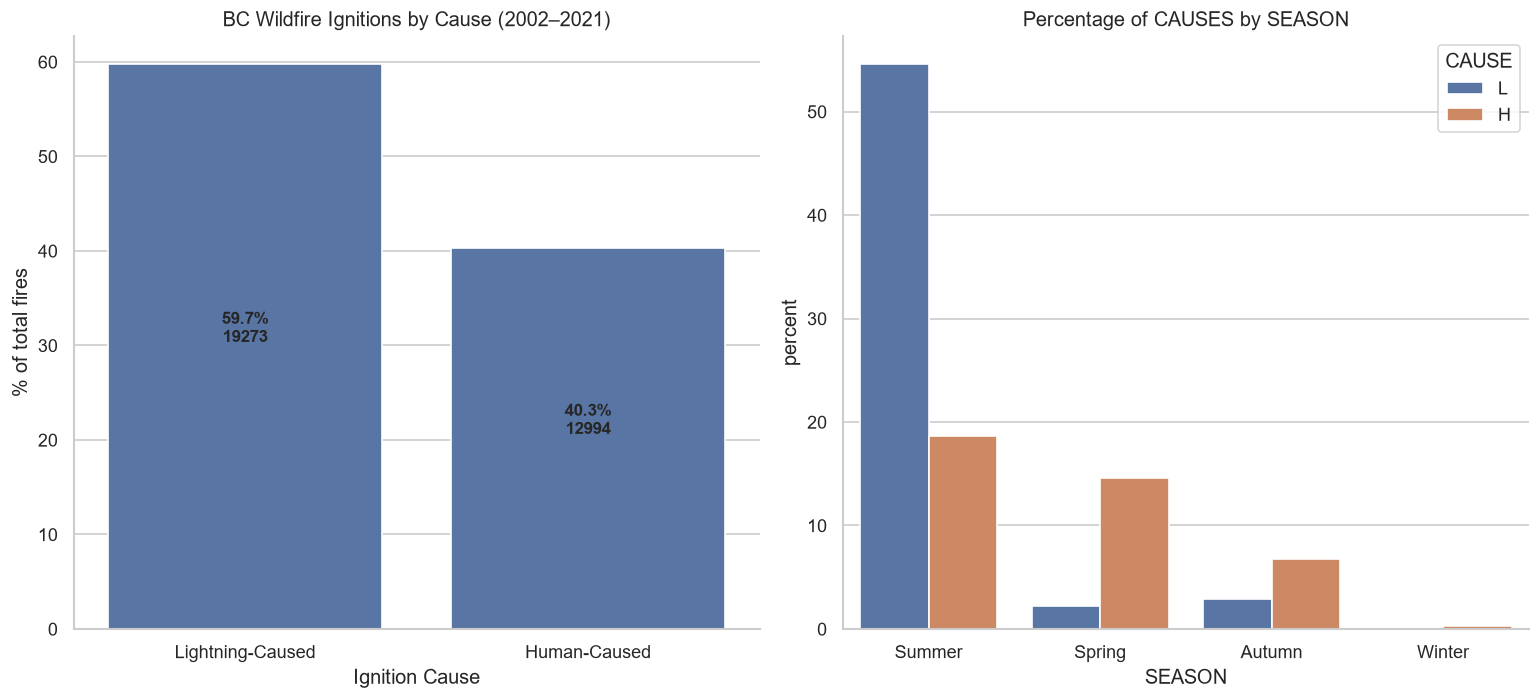

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Initialize plots
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Map values for labels
df['CAUSE_LABEL'] = df['CAUSE'].map({'H': 'Human-Caused', 'L': 'Lightning-Caused'})

# Counts
cause_counts = df['CAUSE_LABEL'].value_counts()
cause_pcts = df['CAUSE_LABEL'].value_counts(normalize=True) * 100

# grouping values

# Graph 1
sns.barplot(x=cause_counts.index, y=cause_pcts.values, ax=axes[0])
axes[0].set_title('BC Wildfire Ignitions by Cause (2002–2021)')
axes[0].set_xlabel('Ignition Cause')
axes[0].set_ylabel('% of total fires')

total = len(df)
#count annotations
for p in axes[0].patches:
    height = p.get_height() # use height because its veritcal instead of width
    count = int(round(height * total / 100))
    axes[0].annotate(f"{height:.1f}%\n{count}", (p.get_x() + p.get_width() / 2., height/2), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

# Graph 2
sns.countplot(df, x="SEASON", hue="CAUSE", stat="percent")
axes[1].set_title("Percentage of CAUSES by SEASON")
axes[1].set_xlabel("SEASON")


sns.despine()
plt.tight_layout()
plt.show()



## 2. Disproving Option B

**Counts:**
 ECOZ_NAME
Montane Cordillera    24712
Pacific Maritime       4885
Boreal PLain           1244
Taiga Plain            1046
Boreal Cordillera       376
                          4
Name: count, dtype: int64

**Percentage:**
 ECOZ_NAME
Montane Cordillera    76.585986
Pacific Maritime      15.139306
Boreal PLain           3.855332
Taiga Plain            3.241702
Boreal Cordillera      1.165277
                       0.012397
Name: proportion, dtype: float64


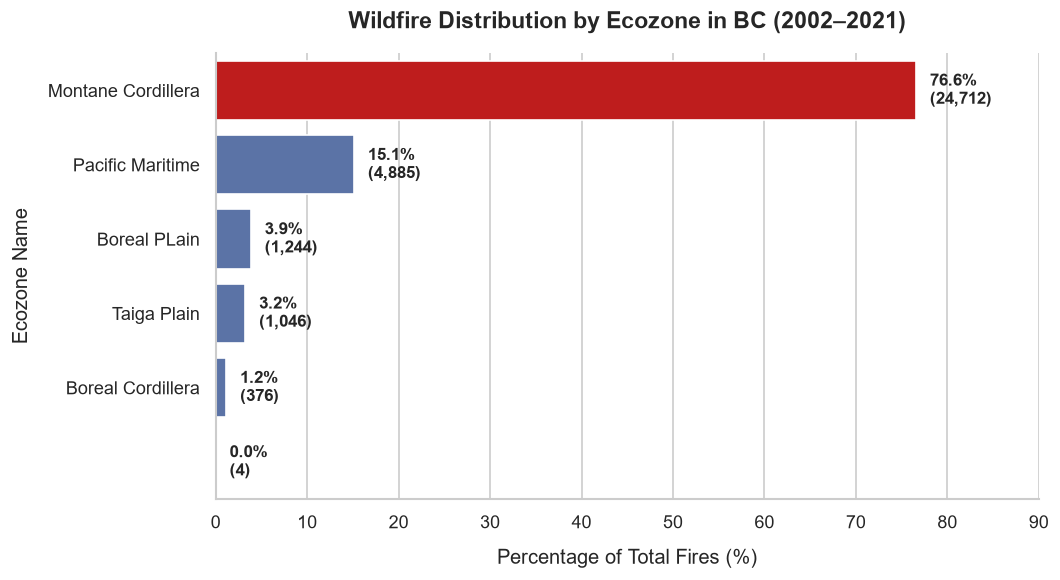

In [85]:
# Ecozone counts and percentages
ecoz_counts = df['ECOZ_NAME'].value_counts()
ecoz_pcts = df['ECOZ_NAME'].value_counts(normalize=True) * 100

print("**Counts:**\n", ecoz_counts)
print("\n**Percentage:**\n", ecoz_pcts)

# Create seaborn plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

# Palette with Montane Cordillera highlighted
palette = ["#d90202" if x == 'Montane Cordillera' else "#4E6EB3" for x in ecoz_counts.index]

ax = sns.barplot(x=ecoz_pcts.values, y=ecoz_counts.index, hue=ecoz_counts.index, palette=palette)

# Annotate bars
total = len(df)
for p in ax.patches:
    width = p.get_width()
    count = int(round(width * total / 100))
    ax.annotate(f'{width:.1f}%\n({count:,})', (width + 1.5, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold')

plt.title('Wildfire Distribution by Ecozone in BC (2002–2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Percentage of Total Fires (%)', fontsize=12, labelpad=10)
plt.ylabel('Ecozone Name', fontsize=12, labelpad=10)
plt.xlim(0, 90)

sns.despine()
plt.tight_layout()
plt.show()

## 3. Option C (LS Classification Model)
I will prepare the data for **Logistic Regression with sklearn (Predictive)** for predicting human-caused and lightning-caused fires based on strong predictors.

#### Filter Dataset
Even though the .csv should not have any entries past or before 2002-2021, I will complete this step just to double check integrity.

In [6]:
df = pd.read_csv('BC_WILDFIRES.csv')
df = df[(df['YEAR'] >= 2002) & (df['YEAR'] <= 2021)].copy()

# handle Blank Strings & Clean Ecozones
df['ECOZ_NAME'] = df['ECOZ_NAME'].str.strip()
df = df[df['ECOZ_NAME'] != ''].copy()

# reset index - Prevents index mismatch during concat
df = df.reset_index(drop=True)

#### Cyclical Month encoding

Data with a cyclical nature (like days of the week or months of the year) often benefit more from cyclical encoding
> Source: https://towardsdatascience.com/scaling-numerical-data-explained-a-visual-guide-with-code-examples-for-beginners-11676cdb45cb/

In [7]:
df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)
engineered = ['MONTH_SIN', 'MONTH_COS']

#### Binary encode target variable

Since this is the variable we're attempting to predict, we will encode it into binary
- H = 1
- L = 0

In [8]:
df['TARGET_CAUSE'] = df['CAUSE'].map({'H': 1, 'L': 0})
df = df.drop(columns=['CAUSE'])

#### Feature Grouping Lists

In [9]:
raw_numeric = ['LATITUDE', 'LONGITUDE', 'YEAR']

#### One-hot encode categorical predictors
Dummy binary columns for model compatibility. This helps sort everything into binary categories.

In [10]:
ecoz_dummies = pd.get_dummies(df['ECOZ_NAME'], prefix='ECOZ_NAME', drop_first=True)
season_dummies = pd.get_dummies(df['SEASON'], prefix='SEASON', drop_first=True)

#### Define Feature Matrix X (EXCLUDING SIZE_HA and LOG_SIZE_HA)

In [11]:
X = pd.concat([df[raw_numeric + engineered], ecoz_dummies, season_dummies], axis=1)
y = df['TARGET_CAUSE']

#### Train/Test Split (Before Scaling)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Scale Continuous Features AFTER Split

In [13]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = raw_numeric + engineered
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

In [15]:
df.head()

,LATITUDE,LONGITUDE,SIZE_HA,ECOZ_NAME,YEAR,MONTH,SEASON,LOG_SIZE_HA,MONTH_SIN,MONTH_COS,TARGET_CAUSE
0,55.8000,-124.8167,0.010,Montane Cordillera,2005,6,Summer,0.009950,1.224647e-16,-1.000000,0
1,59.2448,-131.9168,0.009,Boreal Cordillera,2003,7,Summer,0.008960,-5.000000e-01,-0.866025,0
2,59.7096,-135.0619,0.010,Boreal Cordillera,2003,6,Summer,0.009950,1.224647e-16,-1.000000,1
3,59.4583,-136.3750,0.300,Pacific Maritime,2003,8,Summer,0.262364,-8.660254e-01,-0.500000,1
4,59.1910,-129.2325,0.100,Boreal Cordillera,2003,5,Spring,0.095310,5.000000e-01,-0.866025,1


In [16]:
X.head()

,LATITUDE,LONGITUDE,YEAR,MONTH_SIN,MONTH_COS,ECOZ_NAME_Boreal PLain,ECOZ_NAME_Montane Cordillera,ECOZ_NAME_Pacific Maritime,ECOZ_NAME_Taiga Plain,SEASON_Spring,SEASON_Summer,SEASON_Winter
0,55.8000,-124.8167,2005,1.224647e-16,-1.000000,False,True,False,False,False,True,False
1,59.2448,-131.9168,2003,-5.000000e-01,-0.866025,False,False,False,False,False,True,False
2,59.7096,-135.0619,2003,1.224647e-16,-1.000000,False,False,False,False,False,True,False
3,59.4583,-136.3750,2003,-8.660254e-01,-0.500000,False,False,True,False,False,True,False
4,59.1910,-129.2325,2003,5.000000e-01,-0.866025,False,False,False,False,True,False,False


## Logistic Regression with sklearn (Predictive)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

print(f"Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}")
print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}\n")

# Fit model on existing scaled training data
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Evaluate on existing scaled test data
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score:    {roc_auc_score(y_test, y_prob):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Lightning (0)', 'Human (1)']))

odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds_Ratio': np.exp(lr_model.coef_[0])
}).sort_values(by='Odds_Ratio', ascending=False)

print("\nFeature Coefficients and Odds Ratios:")
print(odds_ratios.to_string(index=False))


Train: (25810, 12)  |  Test: (6453, 12)
Train positive rate: 0.403  |  Test positive rate: 0.403

Overall Accuracy: 0.7838
ROC-AUC Score:    0.8350

               precision    recall  f1-score   support

Lightning (0)       0.78      0.89      0.83      3854
    Human (1)       0.79      0.63      0.70      2599

     accuracy                           0.78      6453
    macro avg       0.79      0.76      0.77      6453
 weighted avg       0.78      0.78      0.78      6453


Feature Coefficients and Odds Ratios:
                     Feature  Coefficient  Odds_Ratio
      ECOZ_NAME_Boreal PLain     2.002380    7.406666
                   MONTH_SIN     1.548701    4.705353
                   MONTH_COS     1.066254    2.904480
                        YEAR    -0.024745    0.975558
               SEASON_Spring    -0.333568    0.716363
  ECOZ_NAME_Pacific Maritime    -0.391539    0.676016
               SEASON_Summer    -0.469640    0.625227
       ECOZ_NAME_Taiga Plain    -0.508262    0.

#### Initial Summary
-- Overrall metrics --

**Accuracy = 78.4%**, Correctly classifies nearly 4 out of 5 newly reported fires province-wide

**ROC-AUC = 0.835**, Demonstrates strong ability to rank-order higher-risk human ignition zones vs. lightning zones

--Cause Prediction--

**Lightning Recall = 89%**, High sensitivity for detecting lightning ignitions

**Human Recall = 63%**, Moderately conservative on human ignitions (avoiding over-prediction)

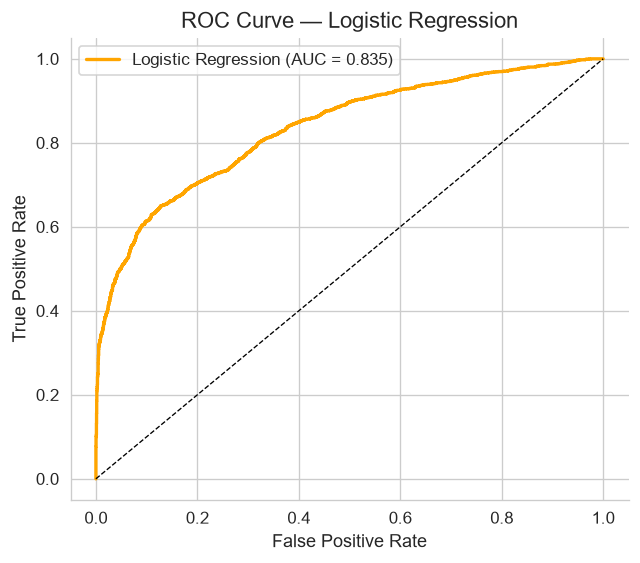

In [18]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='orange', lw=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend()
plt.show()

$\text{AUC} = 0.835$ which indicates solid overall performance above the baseline of a random guess ($\text{AUC} = 0.500$).

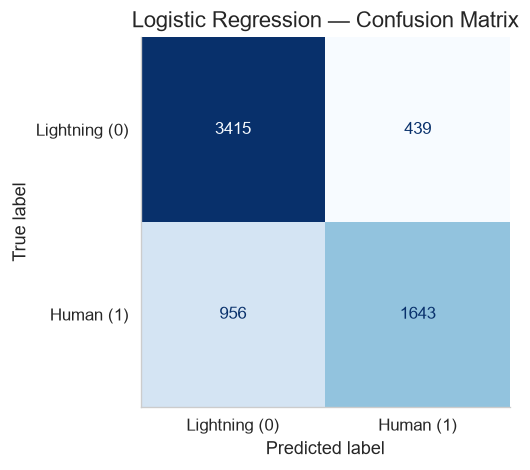

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred)
disp_lr = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr, display_labels=['Lightning (0)', 'Human (1)']
)

fig, ax = plt.subplots(figsize=(5, 4))
disp_lr.plot(ax=ax, cmap='Blues', colorbar=False)
ax.grid(False)
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

### Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

# scale-invariant, so raw X_train / X_test work directly.
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# 3. Print Performance Metrics
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC Score:    {roc_auc_score(y_test, y_prob_rf):.4f}\n")
print("Classification Report:")
print(
    classification_report(
        y_test, y_pred_rf, target_names=['Lightning (0)', 'Human (1)']
    )
)

# for comparison plot
auc_c = roc_auc_score(y_test, y_prob_rf)
fpr_c, tpr_c, _ = roc_curve(y_test, y_prob_rf)

# 4. Extract Feature Importances
importances = pd.DataFrame(
    {'Feature': X.columns, 'Importance': rf_model.feature_importances_}
).sort_values(by='Importance', ascending=False)

print("\nTop Feature Importances:")
print(importances.to_string(index=False))

Overall Accuracy: 0.8391
ROC-AUC Score:    0.9101

Classification Report:
               precision    recall  f1-score   support

Lightning (0)       0.82      0.93      0.87      3854
    Human (1)       0.87      0.71      0.78      2599

     accuracy                           0.84      6453
    macro avg       0.85      0.82      0.83      6453
 weighted avg       0.84      0.84      0.84      6453


Top Feature Importances:
                     Feature  Importance
                    LATITUDE    0.185522
                   LONGITUDE    0.172553
               SEASON_Summer    0.158490
                   MONTH_SIN    0.114613
               SEASON_Spring    0.109579
                        YEAR    0.099609
                   MONTH_COS    0.073233
  ECOZ_NAME_Pacific Maritime    0.038500
ECOZ_NAME_Montane Cordillera    0.024937
       ECOZ_NAME_Taiga Plain    0.015136
      ECOZ_NAME_Boreal PLain    0.007413
               SEASON_Winter    0.000415


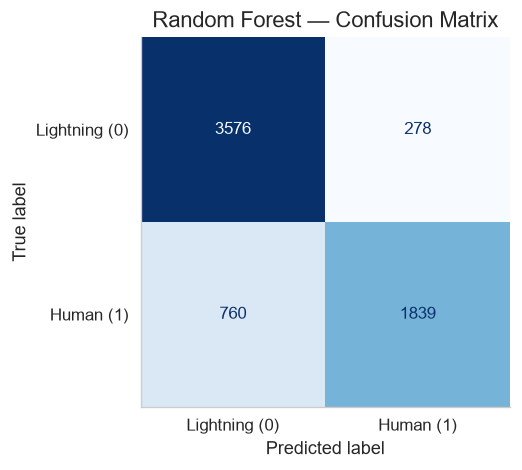

In [34]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf, display_labels=['Lightning (0)', 'Human (1)']
)

fig, ax = plt.subplots(figsize=(5, 4))
disp_rf.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Random Forest — Confusion Matrix')
ax.grid(False)
plt.show()

## Model Comparison

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [auc_lr, auc_c],
    'F1 (class 1)': [
        f1_score(y_test, y_pred, pos_label=1), 
        f1_score(y_test, y_pred_rf, pos_label=1)
    ],
    'Precision (class 1)': [
        precision_score(y_test, y_pred, pos_label=1), 
        precision_score(y_test, y_pred_rf, pos_label=1)
    ],
    'Recall (class 1)': [
        recall_score(y_test, y_pred, pos_label=1), 
        recall_score(y_test, y_pred_rf, pos_label=1)
    ],
}

df_metrics = pd.DataFrame(metrics).set_index('Model').round(4)
df_metrics

,ROC-AUC,F1 (class 1),Precision (class 1),Recall (class 1)
Model,,,,
Logistic Regression,0.8350,0.7020,0.7891,0.6322
Random Forest,0.9101,0.7799,0.8687,0.7076


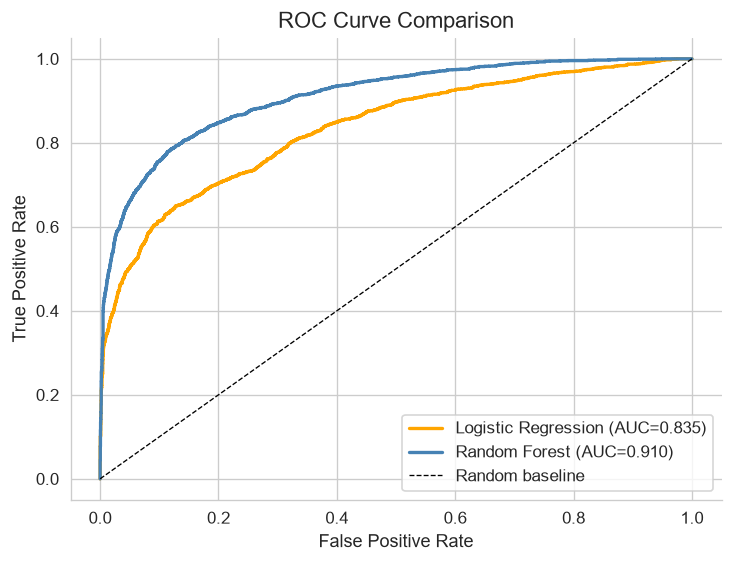

In [36]:
# Dual ROC curve plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='orange', lw=2, label=f'Logistic Regression (AUC={auc_lr:.3f})')
ax.plot(fpr_c, tpr_c, color='steelblue', lw=2, label=f'Random Forest (AUC={auc_c:.3f})')# ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random baseline')
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random baseline')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.show()
